## MLflow Training Pipeline — Customer Churn Prediction

This notebook trains, evaluates, registers, and simulates serving for a customer churn prediction model. It is the MLflow component of the E-Commerce Intelligence Platform.

**Key architectural decisions:**
- **Features come from Feast**, not from a raw Parquet read. This proves training/serving consistency — the same feature store serves both batch training and online inference.
- **Labels come separately from Parquet.** In production, ground truth (did the customer actually churn?) arrives asynchronously after the prediction window closes. Keeping labels separate from the feature store mirrors that reality.
- **Three models, ~10 total runs.** The objective is to demonstrate disciplined experiment tracking rather than exhaustive hyperparameter optimization. No interviewer will criticize you for not running Bayesian optimization. They will notice that experiments are tracked, models are reproducible, and the deployment path is documented.
- **Staging, not Production.** The best model is registered and tagged as Staging. Production promotion requires: validation on unseen temporal data, Evidently drift check, stakeholder approval, and a performance threshold. That's how real ML systems work.
- **Inference simulation at the end.** The registered model is loaded from the registry (not from memory) and used to generate predictions against Feast online features. This produces `predictions.parquet`, which Evidently will consume for drift detection.

**Notebook structure:**
1. Configuration
2. Load Labels
3. Retrieve Features from Feast
4. Assemble Training Dataset
5. Preprocessing
6. Baseline: Logistic Regression
7. LightGBM
8. XGBoost
9. Model Comparison
10. Model Registry
11. Inference Simulation
12. Summary

#### Configuration

In [1]:
import os
import sys
import time
import warnings
import pickle
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    log_loss, confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ──
REPO_ROOT = Path.cwd()
FEAST_REPO = REPO_ROOT / "feast" / "feature_repo"
DATA_DIR = REPO_ROOT / "data"
PARQUET_PATH = DATA_DIR / "churn_feature_dataset.parquet"

# ── MLflow ──
EXPERIMENT_NAME = "ecommerce-churn-v1"
MLFLOW_DB = REPO_ROOT / "mlflow.db"
MODEL_NAME = "ecommerce-churn-model"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment(EXPERIMENT_NAME)

# ── Feature list (frozen schema v1 — see docs/feature_schema.md) ──
# These 21 features are the training inputs. price_sensitivity_score is
# excluded: it has zero variance in TheLook (sale_price == retail_price
# universally). See docs/feature_schema.md Section 7 for the rationale.
FEATURE_COLUMNS = [
    # Transactional (7)
    "order_count",
    "lifetime_spend",
    "avg_order_value",
    "days_since_last_order",
    "first_to_second_order_days",
    "total_items_purchased",
    "return_rate",
    # Behavioral (6)
    "total_sessions",
    "session_count_30d",
    "avg_session_depth",
    "browse_to_buy_ratio",
    "cart_abandonment_rate",
    "days_since_last_session",
    # Product interaction (3) — price_sensitivity_score excluded
    "distinct_products_purchased",
    "distinct_categories_purchased",
    "favorite_category",
    # Demographic (5)
    "age",
    "gender",
    "country",
    "traffic_source",
    "account_age_days",
]

CATEGORICAL_COLUMNS = ["gender", "country", "traffic_source", "favorite_category"]
LABEL_COLUMN = "churned"
RANDOM_STATE = 42

print("=" * 60)
print("  MLFLOW TRAINING PIPELINE — CONFIGURATION")
print("=" * 60)
print(f"  Repo root:       {REPO_ROOT}")
print(f"  Feast repo:      {FEAST_REPO}")
print(f"  Parquet:         {PARQUET_PATH}")
print(f"  MLflow tracking: sqlite:///{MLFLOW_DB}")
print(f"  Experiment:      {EXPERIMENT_NAME}")
print(f"  Features:        {len(FEATURE_COLUMNS)} (excl. price_sensitivity_score)")
print(f"  Categoricals:    {CATEGORICAL_COLUMNS}")
print(f"  Label:           {LABEL_COLUMN}")
print("=" * 60)

/opt/homebrew/Caskroom/miniforge/base/envs/lakehouse/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  MLFLOW TRAINING PIPELINE — CONFIGURATION
  Repo root:       /Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops
  Feast repo:      /Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops/feast/feature_repo
  Parquet:         /Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops/data/churn_feature_dataset.parquet
  MLflow tracking: sqlite:////Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops/mlflow.db
  Experiment:      ecommerce-churn-v1
  Features:        21 (excl. price_sensitivity_score)
  Categoricals:    ['gender', 'country', 'traffic_source', 'favorite_category']
  Label:           churned


#### Load Labels

In production, ground truth arrives asynchronously, a customer's churn status is only known after the 90-day prediction window closes. The feature store does not contain labels because labels are not features. This separation is intentional: the training pipeline reads features from Feast and labels from a separate source.

Here we load only `user_id` and `churned` from the Parquet file.

In [2]:
labels_df = pd.read_parquet(PARQUET_PATH, columns=["user_id", LABEL_COLUMN])

print(f"  Labels loaded: {len(labels_df):,} rows")
print(f"  Churn rate:    {labels_df[LABEL_COLUMN].mean():.1%}")
print(f"  Churned:       {labels_df[LABEL_COLUMN].sum():,}")
print(f"  Not churned:   {(labels_df[LABEL_COLUMN] == 0).sum():,}")

  Labels loaded: 62,000 rows
  Churn rate:    92.9%
  Churned:       57,572
  Not churned:   4,428


#### Retrieve Features from Feast

This is the training path. We pass an entity DataFrame (all 62,000 eligible customers with a request timestamp) to Feast's `get_historical_features()`. Feast returns point-in-time correct features from the offline store, the same API that would be called by a scheduled retraining job in production.

The result is a pandas DataFrame with 22 feature columns (we'll drop `price_sensitivity_score` in the next section).

In [4]:
sys.path.insert(0, str(FEAST_REPO))
os.chdir(FEAST_REPO)

from feast import FeatureStore
from features import churn_prediction_service

store = FeatureStore(repo_path=str(FEAST_REPO))

# Build entity DataFrame — all eligible customers at a single point in time
entity_df = pd.DataFrame({
    "user_id": labels_df["user_id"].values,
    "event_timestamp": [datetime.now(timezone.utc)] * len(labels_df),
})

print(f"  Retrieving features for {len(entity_df):,} customers from Feast...")
t0 = time.time()

features_df = store.get_historical_features(
    entity_df=entity_df,
    features=churn_prediction_service,
).to_df()

elapsed = round(time.time() - t0, 1)

os.chdir(REPO_ROOT)

print(f"  ✓ Features retrieved in {elapsed}s")
print(f"  Shape: {features_df.shape}")
print(f"  Columns: {list(features_df.columns)}")

  Retrieving features for 62,000 customers from Feast...
  ✓ Features retrieved in 0.6s
  Shape: (62000, 24)
  Columns: ['user_id', 'event_timestamp', 'order_count', 'lifetime_spend', 'avg_order_value', 'days_since_last_order', 'first_to_second_order_days', 'total_items_purchased', 'return_rate', 'total_sessions', 'session_count_30d', 'avg_session_depth', 'browse_to_buy_ratio', 'cart_abandonment_rate', 'days_since_last_session', 'distinct_products_purchased', 'distinct_categories_purchased', 'favorite_category', 'price_sensitivity_score', 'age', 'gender', 'country', 'traffic_source', 'account_age_days']


#### Assemble Training Dataset

Merge Feast features with Parquet labels on `user_id`. Drop metadata and the zero-variance `price_sensitivity_score`. The result is a clean training dataset: 21 features + 1 target.

In [5]:
# Merge features (from Feast) with labels (from Parquet)
training_df = features_df.merge(labels_df, on="user_id", how="inner")

# Drop metadata columns that aren't features
drop_cols = [c for c in ["event_timestamp", "price_sensitivity_score"] if c in training_df.columns]
training_df = training_df.drop(columns=drop_cols)

print("=" * 60)
print("  TRAINING DATASET")
print("=" * 60)
print(f"  Rows:     {len(training_df):,}")
print(f"  Columns:  {len(training_df.columns)} ({len(training_df.columns) - 2} features + user_id + label)")
print(f"  Features: {[c for c in training_df.columns if c not in ['user_id', LABEL_COLUMN]]}")
print(f"  Label:    {LABEL_COLUMN} (churn rate: {training_df[LABEL_COLUMN].mean():.1%})")
print("=" * 60)

  TRAINING DATASET
  Rows:     62,000
  Columns:  23 (21 features + user_id + label)
  Features: ['order_count', 'lifetime_spend', 'avg_order_value', 'days_since_last_order', 'first_to_second_order_days', 'total_items_purchased', 'return_rate', 'total_sessions', 'session_count_30d', 'avg_session_depth', 'browse_to_buy_ratio', 'cart_abandonment_rate', 'days_since_last_session', 'distinct_products_purchased', 'distinct_categories_purchased', 'favorite_category', 'age', 'gender', 'country', 'traffic_source', 'account_age_days']
  Label:    churned (churn rate: 92.9%)


#### Preprocessing

**Train/test split:** 80/20, stratified on `churned` to preserve the 92.9%/7.1% class ratio in both sets.

**Categorical encoding:** Although LightGBM supports categorical features directly, a shared preprocessing pipeline is used so that Logistic Regression, XGBoost, and LightGBM are evaluated on an identical feature representation. This isolates differences in model performance from differences in preprocessing.

**Null handling:** `first_to_second_order_days` is null for single-order customers (no second order exists). Filled with -1 as a sentinel value — tree-based models handle this naturally via split logic, and logistic regression treats it as an ordinal value below the minimum real gap.

**Encoders are persisted as MLflow artifacts** so the registered model is self-contained — load the model from registry, load the encoders from the same run, and inference works without the training notebook.

In [6]:
# ── Separate features and target ──
feature_df = training_df[FEATURE_COLUMNS].copy()
target = training_df[LABEL_COLUMN].copy()

# ── Null handling ──
# first_to_second_order_days: null for single-order customers
feature_df["first_to_second_order_days"] = feature_df["first_to_second_order_days"].fillna(-1)

# Fill remaining nulls in numeric columns with 0
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
feature_df[numeric_cols] = feature_df[numeric_cols].fillna(0)

# ── Encode categoricals ──
encoders = {}
for col in CATEGORICAL_COLUMNS:
    le = LabelEncoder()
    feature_df[col] = feature_df[col].fillna("Unknown")
    feature_df[col] = le.fit_transform(feature_df[col])
    encoders[col] = le
    print(f"  Encoded {col}: {len(le.classes_)} classes")

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target,
    test_size=0.2,
    stratify=target,
    random_state=RANDOM_STATE,
)

# ── Class ratio for imbalance handling ──
class_ratio = (y_train == 1).sum() / (y_train == 0).sum()

print(f"\n  Train: {len(X_train):,} rows ({y_train.mean():.1%} churn)")
print(f"  Test:  {len(X_test):,} rows ({y_test.mean():.1%} churn)")
print(f"  Class ratio (churned/not): {class_ratio:.1f}")
print(f"  Features: {X_train.shape[1]}  |  Encoders: {len(encoders)}")

  Encoded gender: 2 classes
  Encoded country: 14 classes
  Encoded traffic_source: 5 classes
  Encoded favorite_category: 27 classes

  Train: 49,600 rows (92.9% churn)
  Test:  12,400 rows (92.9% churn)
  Class ratio (churned/not): 13.0
  Features: 21  |  Encoders: 4


#### Training Utilities

In [7]:
def evaluate_model(model, X_test, y_test):
    """Compute all metrics for a trained model."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "auc_roc": round(roc_auc_score(y_test, y_prob), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "log_loss": round(log_loss(y_test, y_prob), 4),
    }


def log_plots(model, X_test, y_test, run_name):
    """Generate and log confusion matrix and ROC curve as MLflow artifacts."""

    # Confusion matrix
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax_cm, cmap="Blues")
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    cm_path = f"/tmp/{run_name}_confusion_matrix.png"
    fig_cm.savefig(cm_path, dpi=100, bbox_inches="tight")
    plt.close(fig_cm)
    mlflow.log_artifact(cm_path)

    # ROC curve
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)

    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    ax_roc.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}", linewidth=2)
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"ROC Curve — {run_name}")
    ax_roc.legend()
    roc_path = f"/tmp/{run_name}_roc_curve.png"
    fig_roc.savefig(roc_path, dpi=100, bbox_inches="tight")
    plt.close(fig_roc)
    mlflow.log_artifact(roc_path)


def log_feature_importance(model, feature_names, run_name, top_n=15):
    """Log feature importance plot for tree-based models."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(indices)), importances[indices], align="center", color="#2196F3")
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} Features — {run_name}")
    fi_path = f"/tmp/{run_name}_feature_importance.png"
    fig.savefig(fi_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact(fi_path)


def log_encoders(encoders):
    """Persist label encoders as MLflow artifacts for inference reproducibility."""
    for col, le in encoders.items():
        enc_path = f"/tmp/encoder_{col}.pkl"
        with open(enc_path, "wb") as f:
            pickle.dump(le, f)
        mlflow.log_artifact(enc_path)


def train_and_log(model, model_name, run_name, params, X_train, y_train, X_test, y_test, encoders, log_importance=False):
    """Train a model, evaluate it, and log everything to MLflow."""
    with mlflow.start_run(run_name=run_name):
        # Train
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = round(time.time() - t0, 2)

        # Evaluate
        metrics = evaluate_model(model, X_test, y_test)
        metrics["training_time_sec"] = train_time

        # Log
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, "model",serialization_format="pickle",)
        log_plots(model, X_test, y_test, run_name)
        log_encoders(encoders)

        if log_importance and hasattr(model, "feature_importances_"):
            log_feature_importance(model, list(X_train.columns), run_name)

        # Tag
        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("feature_version", "v1")
        mlflow.set_tag("training_rows", len(X_train))

        run_id = mlflow.active_run().info.run_id

        print(f"  ✓ {run_name}")
        print(f"    AUC: {metrics['auc_roc']:.4f}  |  F1: {metrics['f1']:.4f}  |  Time: {train_time}s")

        return run_id, metrics

#### Baseline: Logistic Regression

The baseline establishes a floor. Any tree-based model that doesn't beat logistic regression isn't worth the complexity. `class_weight="balanced"` adjusts for the 92.9% churn rate by upweighting the minority class.

In [8]:
print("=" * 60)
print("  BASELINE: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver="lbfgs",
)

lr_params = {
    "model_type": "LogisticRegression",
    "class_weight": "balanced",
    "max_iter": 1000,
    "solver": "lbfgs",
}

lr_run_id, lr_metrics = train_and_log(
    model=lr_model,
    model_name="LogisticRegression",
    run_name="lr_baseline",
    params=lr_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    encoders=encoders,
    log_importance=False,
)

  BASELINE: LOGISTIC REGRESSION


2026/07/26 13:16:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ lr_baseline
    AUC: 0.7147  |  F1: 0.7679  |  Time: 0.86s


#### LightGBM

Four parameter combinations varying learning rate and model complexity. `is_unbalance=True` handles the 92.9% class imbalance by adjusting sample weights internally. `verbose=-1` suppresses training output.

In [9]:
print("=" * 60)
print("  LIGHTGBM EXPERIMENTS")
print("=" * 60)

lgb_configs = [
    {"learning_rate": 0.05, "num_leaves": 31,  "n_estimators": 100},
    {"learning_rate": 0.05, "num_leaves": 63,  "n_estimators": 200},
    {"learning_rate": 0.1,  "num_leaves": 31,  "n_estimators": 100},
    {"learning_rate": 0.1,  "num_leaves": 63,  "n_estimators": 200},
]

lgb_results = []

for i, cfg in enumerate(lgb_configs):
    run_name = f"lgb_{cfg['learning_rate']}lr_{cfg['num_leaves']}lv_{cfg['n_estimators']}est"

    model = lgb.LGBMClassifier(
        **cfg,
        is_unbalance=True,
        random_state=RANDOM_STATE,
        verbose=-1,
    )

    params = {**cfg, "model_type": "LightGBM", "is_unbalance": True}

    run_id, metrics = train_and_log(
        model=model,
        model_name="LightGBM",
        run_name=run_name,
        params=params,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        encoders=encoders,
        log_importance=True,
    )
    lgb_results.append({"run_name": run_name, "run_id": run_id, **metrics})

print(f"\n  LightGBM: {len(lgb_results)} runs complete.")

  LIGHTGBM EXPERIMENTS


2026/07/26 13:16:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ lgb_0.05lr_31lv_100est
    AUC: 0.7417  |  F1: 0.8442  |  Time: 0.78s


2026/07/26 13:16:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ lgb_0.05lr_63lv_200est
    AUC: 0.7282  |  F1: 0.8803  |  Time: 2.88s


2026/07/26 13:16:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ lgb_0.1lr_31lv_100est
    AUC: 0.7327  |  F1: 0.8550  |  Time: 0.75s


2026/07/26 13:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ lgb_0.1lr_63lv_200est
    AUC: 0.7168  |  F1: 0.9031  |  Time: 2.86s

  LightGBM: 4 runs complete.


#### XGBoost

Four parameter combinations. `scale_pos_weight` is set to the class ratio (~13.0) to handle imbalance — this upweights the minority class by the ratio of majority to minority samples.

In [10]:
print("=" * 60)
print("  XGBOOST EXPERIMENTS")
print("=" * 60)

xgb_configs = [
    {"learning_rate": 0.05, "max_depth": 4, "n_estimators": 100},
    {"learning_rate": 0.05, "max_depth": 6, "n_estimators": 200},
    {"learning_rate": 0.1,  "max_depth": 4, "n_estimators": 100},
    {"learning_rate": 0.1,  "max_depth": 6, "n_estimators": 200},
]

xgb_results = []

for i, cfg in enumerate(xgb_configs):
    run_name = f"xgb_{cfg['learning_rate']}lr_{cfg['max_depth']}d_{cfg['n_estimators']}est"

    model = xgb.XGBClassifier(
        **cfg,
        scale_pos_weight=class_ratio,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False,
    )

    params = {
        **cfg,
        "model_type": "XGBoost",
        "scale_pos_weight": round(class_ratio, 1),
    }

    run_id, metrics = train_and_log(
        model=model,
        model_name="XGBoost",
        run_name=run_name,
        params=params,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        encoders=encoders,
        log_importance=True,
    )
    xgb_results.append({"run_name": run_name, "run_id": run_id, **metrics})

print(f"\n  XGBoost: {len(xgb_results)} runs complete.")

2026/07/26 13:16:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  XGBOOST EXPERIMENTS


2026/07/26 13:16:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ xgb_0.05lr_4d_100est
    AUC: 0.7343  |  F1: 0.9630  |  Time: 0.17s


2026/07/26 13:16:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 13:16:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  ✓ xgb_0.05lr_6d_200est
    AUC: 0.7391  |  F1: 0.9630  |  Time: 0.45s
  ✓ xgb_0.1lr_4d_100est
    AUC: 0.7392  |  F1: 0.9630  |  Time: 0.16s


2026/07/26 13:16:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:16:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ xgb_0.1lr_6d_200est
    AUC: 0.7399  |  F1: 0.9630  |  Time: 0.45s

  XGBoost: 4 runs complete.


#### Model Comparison

All runs from the experiment, side by side. Sorted by AUC-ROC descending. The best model is the one we register.

  MODEL COMPARISON

              run_name  auc_roc  precision  recall     f1  log_loss  training_time_sec
lgb_0.05lr_31lv_100est   0.7417     0.9623  0.7519 0.8442    0.5420               0.78
   xgb_0.1lr_6d_200est   0.7399     0.9285  1.0000 0.9630    0.3360               0.45
   xgb_0.1lr_4d_100est   0.7392     0.9285  1.0000 0.9630    0.3406               0.16
  xgb_0.05lr_6d_200est   0.7391     0.9285  1.0000 0.9630    0.3380               0.45
  xgb_0.05lr_4d_100est   0.7343     0.9285  1.0000 0.9630    0.3351               0.17
 lgb_0.1lr_31lv_100est   0.7327     0.9601  0.7706 0.8550    0.5224               0.75
lgb_0.05lr_63lv_200est   0.7282     0.9571  0.8150 0.8803    0.4662               2.88
 lgb_0.1lr_63lv_200est   0.7168     0.9536  0.8576 0.9031    0.4053               2.86
           lr_baseline   0.7147     0.9627  0.6386 0.7679    0.6143               0.86

  Best model: lgb_0.05lr_31lv_100est  (AUC: 0.7417)


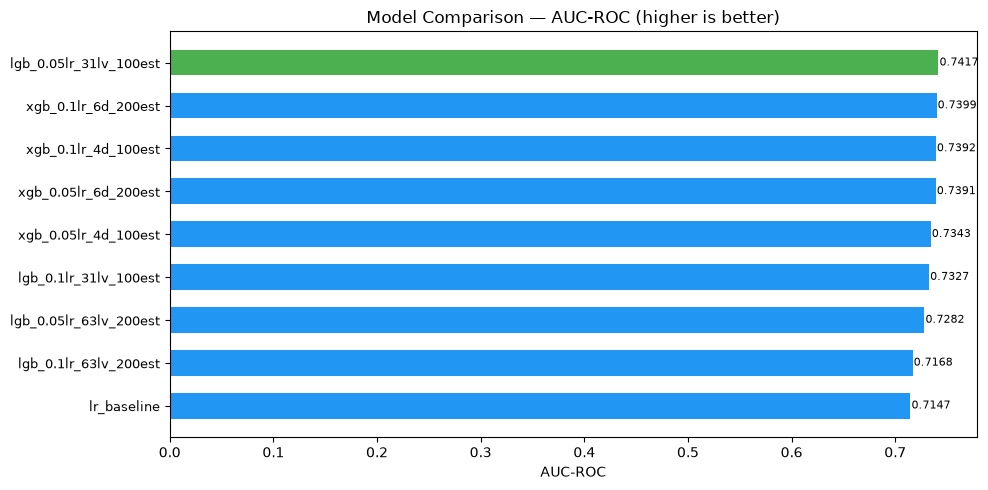


  Chart saved to /tmp/model_comparison.png


In [11]:
# Collect all results
all_results = (
    [{"run_name": "lr_baseline", "run_id": lr_run_id, **lr_metrics}]
    + lgb_results
    + xgb_results
)

results_df = pd.DataFrame(all_results).sort_values("auc_roc", ascending=False).reset_index(drop=True)

print("=" * 60)
print("  MODEL COMPARISON")
print("=" * 60)
print()
print(results_df[["run_name", "auc_roc", "precision", "recall", "f1", "log_loss", "training_time_sec"]].to_string(index=False))

best = results_df.iloc[0]
print(f"\n  Best model: {best['run_name']}  (AUC: {best['auc_roc']:.4f})")

# ── Visualization ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4CAF50" if i == 0 else "#2196F3" for i in range(len(results_df))]
ax.barh(range(len(results_df)), results_df["auc_roc"], color=colors, height=0.6)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["run_name"], fontsize=9)
ax.set_xlabel("AUC-ROC")
ax.set_title("Model Comparison — AUC-ROC (higher is better)")
ax.invert_yaxis()
for i, v in enumerate(results_df["auc_roc"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout()
comparison_path = "/tmp/model_comparison.png"
fig.savefig(comparison_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"\n  Chart saved to {comparison_path}")

#### Model Selection Rationale

LightGBM (learning_rate=0.05, num_leaves=31, n_estimators=100) was selected as the production model because it achieved the highest AUC-ROC (0.7417) across all evaluated models. AUC-ROC was used as the primary model selection metric because it evaluates ranking performance across all classification thresholds and is well suited to highly imbalanced datasets such as this one (92.9% churn). The observed performance is consistent with the characteristics of the available feature space, where many customers exhibit limited behavioral history (for example, a single order and few sessions), reducing the amount of discriminative signal available to the models.

#### Model Registry

Register the best model in MLflow Model Registry under `ecommerce-churn-model`. Tag it as **Staging**. Document what production promotion requires.

Promotion to Production requires:
- Validation on a temporally distinct holdout (e.g., next month's data)
- Evidently drift check passes (no feature with PSI > 0.1)
- Stakeholder approval from the CRM/Marketing team
- AUC-ROC above a defined performance threshold

In [12]:
best_run_id = best["run_id"]
best_run_name = best["run_name"]
model_uri = f"runs:/{best_run_id}/model"

print("=" * 60)
print("  MODEL REGISTRY")
print("=" * 60)
print(f"  Registering: {best_run_name} (AUC: {best['auc_roc']:.4f})")
print(f"  Run ID:      {best_run_id}")
print(f"  Model URI:   {model_uri}")

# Register the model
result = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)

print(f"\n  ✓ Registered as: {result.name} v{result.version}")
print(f"  Stage: Staging")

# Tag the registered model version
client = mlflow.MlflowClient()

client.set_model_version_tag(
    name=MODEL_NAME,
    version=result.version,
    key="feature_version",
    value="v1",
)
client.set_model_version_tag(
    name=MODEL_NAME,
    version=result.version,
    key="training_rows",
    value=str(len(X_train)),
)
client.set_model_version_tag(
    name=MODEL_NAME,
    version=result.version,
    key="churn_rate",
    value=f"{y_train.mean():.3f}",
)
client.set_model_version_tag(
    name=MODEL_NAME,
    version=result.version,
    key="auc_roc",
    value=str(best["auc_roc"]),
)

# Transition to Staging
try:
    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=result.version,
        stage="Staging",
    )
except Exception:
    # MLflow 3.x may use aliases instead of stages
    try:
        client.set_registered_model_alias(MODEL_NAME, "staging", result.version)
        print("  (Used alias 'staging' — MLflow 3.x API)")
    except Exception as e:
        print(f"  Note: Stage/alias not set ({e}). Model is still registered.")

print(f"\n  Production promotion criteria:")
print(f"    1. Validate on temporally distinct holdout data")
print(f"    2. Evidently drift check passes (PSI < 0.1)")
print(f"    3. Stakeholder approval from CRM/Marketing")
print(f"    4. AUC-ROC >= defined threshold")
print("=" * 60)

Registered model 'ecommerce-churn-model' already exists. Creating a new version of this model...
2026/07/26 13:17:24 WARNING mlflow.tracking._model_registry.fluent: Run with id 90383ca30bd947988d67370fbbb41b29 has no artifacts at artifact path 'model', registering model based on models:/m-0ae30e5e50bb47889ffc4643e320c060 instead


  MODEL REGISTRY
  Registering: lgb_0.05lr_31lv_100est (AUC: 0.7417)
  Run ID:      90383ca30bd947988d67370fbbb41b29
  Model URI:   runs:/90383ca30bd947988d67370fbbb41b29/model

  ✓ Registered as: ecommerce-churn-model v2
  Stage: Staging

  Production promotion criteria:
    1. Validate on temporally distinct holdout data
    2. Evidently drift check passes (PSI < 0.1)
    3. Stakeholder approval from CRM/Marketing
    4. AUC-ROC >= defined threshold


Created version '2' of model 'ecommerce-churn-model'.
/var/folders/yd/f40h2d312dggyb2s4268_n400000gn/T/ipykernel_45922/3770736750.py:48: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


#### Inference Simulation

This section proves the serving path works end-to-end. Instead of using the in-memory model from training, we **load the registered model from the MLflow registry** — exactly what happens in production. Features are pulled from Feast's online store (not the offline store used for training), demonstrating that the serving infrastructure is functional.

The output `data/predictions.parquet` gives Evidently a real inference dataset to compare against the training feature distributions for drift detection.

In [13]:
print("=" * 60)
print("  INFERENCE SIMULATION")
print("=" * 60)

# ── Load the registered model from MLflow (not from memory) ──
print("  Loading model from MLflow registry...")
model_uri_registry = f"models:/{MODEL_NAME}/{result.version}"

try:
    serving_model = mlflow.sklearn.load_model(model_uri_registry)
except Exception:
    # Fallback: load from the run directly
    serving_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")
    print("  (Loaded from run URI — registry URI may need MLflow server)")

# ── Load encoders from the best run ──
artifact_dir = mlflow.artifacts.download_artifacts(run_id=best_run_id)
serving_encoders = {}
for col in CATEGORICAL_COLUMNS:
    enc_path = os.path.join(artifact_dir, f"encoder_{col}.pkl")
    with open(enc_path, "rb") as f:
        serving_encoders[col] = pickle.load(f)
print(f"  ✓ Model and {len(serving_encoders)} encoders loaded from registry")

# ── Pull online features from Feast for 1,000 customers ──
print("  Pulling online features for 1,000 customers...")
os.chdir(FEAST_REPO)
store_serving = FeatureStore(repo_path=str(FEAST_REPO))

sample_ids = labels_df["user_id"].sample(n=1000, random_state=RANDOM_STATE).tolist()

online_response = store_serving.get_online_features(
    features=[
        f"customer_churn_features:{f}" for f in FEATURE_COLUMNS
        if f != "price_sensitivity_score"  # excluded from training
    ],
    entity_rows=[{"user_id": uid} for uid in sample_ids],
).to_dict()

os.chdir(REPO_ROOT)

inference_df = pd.DataFrame(online_response)
print(f"  ✓ Online features retrieved: {inference_df.shape}")

# ── Preprocess for inference ──
for col in CATEGORICAL_COLUMNS:
    inference_df[col] = inference_df[col].fillna("Unknown")
    le = serving_encoders[col]
    # Handle unseen categories gracefully
    inference_df[col] = inference_df[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

inference_df["first_to_second_order_days"] = inference_df["first_to_second_order_days"].fillna(-1)
numeric_cols_inf = inference_df.select_dtypes(include=[np.number]).columns
inference_df[numeric_cols_inf] = inference_df[numeric_cols_inf].fillna(0)

# ── Generate predictions ──
feature_cols_for_pred = [c for c in FEATURE_COLUMNS if c != "price_sensitivity_score"]
X_inference = inference_df[feature_cols_for_pred]
churn_probabilities = serving_model.predict_proba(X_inference)[:, 1]
predicted_labels = (churn_probabilities >= 0.5).astype(int)

# ── Save predictions ──
predictions_df = pd.DataFrame({
    "user_id": sample_ids,
    "churn_probability": np.round(churn_probabilities, 4),
    "predicted_label": predicted_labels,
    "prediction_timestamp": datetime.now(timezone.utc),
    "model_name": MODEL_NAME,
    "model_version": str(result.version),
})

predictions_path = DATA_DIR / "predictions.parquet"
predictions_df.to_parquet(predictions_path, index=False)

print(f"\n  Predictions saved: {predictions_path}")
print(f"  Rows: {len(predictions_df):,}")
print(f"  Predicted churn rate: {predicted_labels.mean():.1%}")
print(f"  Mean churn probability: {churn_probabilities.mean():.3f}")
print("=" * 60)

  INFERENCE SIMULATION
  Loading model from MLflow registry...
  ✓ Model and 4 encoders loaded from registry
  Pulling online features for 1,000 customers...
  ✓ Online features retrieved: (1000, 22)

  Predictions saved: /Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops/data/predictions.parquet
  Rows: 1,000
  Predicted churn rate: 70.8%
  Mean churn probability: 0.606


#### Summary

In [14]:
print("=" * 60)
print("  TRAINING PIPELINE SUMMARY")
print("=" * 60)
print(f"\n  Experiment:       {EXPERIMENT_NAME}")
print(f"  Total runs:       {len(all_results)}")
print(f"  Best model:       {best['run_name']}")
print(f"  AUC-ROC:          {best['auc_roc']:.4f}")
print(f"  F1:               {best['f1']:.4f}")
print(f"  Precision:        {best['precision']:.4f}")
print(f"  Recall:           {best['recall']:.4f}")
print(f"  Training time:    {best['training_time_sec']}s")
print(f"\n  Registered model: {MODEL_NAME} v{result.version}")
print(f"  Stage:            Staging")
print(f"  Feature version:  v1")
print(f"  Training rows:    {len(X_train):,}")
print(f"  Predictions:      {predictions_path}")
print(f"\n  Next step:")
print(f"    Evidently AI will compare training feature distributions")
print(f"    against inference feature distributions (predictions.parquet)")
print(f"    to detect data drift. If PSI > 0.1 for any feature, a")
print(f"    retraining alert is triggered.")
print("=" * 60)

  TRAINING PIPELINE SUMMARY

  Experiment:       ecommerce-churn-v1
  Total runs:       9
  Best model:       lgb_0.05lr_31lv_100est
  AUC-ROC:          0.7417
  F1:               0.8442
  Precision:        0.9623
  Recall:           0.7519
  Training time:    0.78s

  Registered model: ecommerce-churn-model v2
  Stage:            Staging
  Feature version:  v1
  Training rows:    49,600
  Predictions:      /Users/prathamesh/2026 Portfolio Projects/ecommerce-lakehouse-mlops/data/predictions.parquet

  Next step:
    Evidently AI will compare training feature distributions
    against inference feature distributions (predictions.parquet)
    to detect data drift. If PSI > 0.1 for any feature, a
    retraining alert is triggered.
